LOADING DATASETS AND FUNCTIONS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import math
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
data_path = "/content/drive/MyDrive/Colab Notebooks/train.csv"
df = pd.read_csv(data_path)
bad_names = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'Id','MiscVal','MSSubClass','PoolArea','BedroomAbvGr','KitchenAbvGr','YrSold','MoSold','3SsnPorch','OpenPorchSF','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','LowQualFinSF','EnclosedPorch','ScreenPorch','BsmtFinSF2']
for name, data in df.items():
  try:
    num = float(data[0])
    if math.isnan(data[0]):
      df = df.drop(name, axis=1)
  except:
    df = df.drop(name, axis=1)
  if name in bad_names:
    df = df.drop(name, axis=1)

Mounted at /content/drive


In [ ]:
def generate_dataset(scales, importances, n):
  y = []
  X = []

  for i in range(n):
    inputs = []
    for j in range(len(scales)):
      inputs.append(scales[j] * np.random.rand())
    X.append(inputs)

  for i in range(n):
    output = 0
    for j in range(len(scales)):
      output += (importances[j] * X[i][j])
    y.append(output)

  error_pct = max(y) / 3

  for i in range(len(y)):
    y[i] = y[i] + np.random.normal(scale=error_pct)

  return X, y

In [ ]:
def eval_models(a_val, X, y):
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)
    linear = sklearn.linear_model.LinearRegression()
    linear.fit(X_train, y_train)
    linear_guesses = linear.predict(X_test)
    linear_mse = sklearn.metrics.mean_squared_error(linear_guesses, y_test)

    ridge = sklearn.linear_model.Ridge(alpha=a_val)
    ridge.fit(X_train, y_train)
    ridge_guesses = ridge.predict(X_test)
    ridge_mse = sklearn.metrics.mean_squared_error(ridge_guesses, y_test)

    scaler = sklearn.preprocessing.StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.fit_transform(X_test)

    ridge_std = sklearn.linear_model.Ridge(alpha=a_val)
    ridge_std.fit(X_train_std, y_train)
    ridge_std_guesses = ridge_std.predict(X_test_std)
    ridge_std_mse = sklearn.metrics.mean_squared_error(ridge_std_guesses, y_test)

    return linear_mse, linear.coef_, ridge_mse, ridge.coef_, ridge_std_mse, ridge_std.coef_

EXPLORING SYNTHETIC DATA

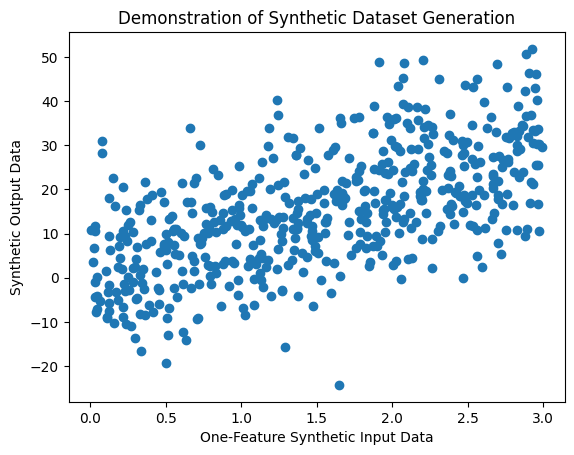

In [ ]:
scale = [3]
multiplier = [10]
X, y = generate_dataset(scale, multiplier, 540)
plt.scatter(X, y)
plt.xlabel('One-Feature Synthetic Input Data')
plt.ylabel('Synthetic Output Data')
plt.title('Demonstration of Synthetic Dataset Generation')
plt.show()

In [ ]:
scales = [4,2,3,0.25,6,10000000,3]
multipliers = [1,1,1,1,1,(1/1000000000),1]
n = 2000
a = 10

X, y = generate_dataset(scales, multipliers, n)
outputs = eval_models(a, X, y)

print('Linear MSE: ' + str(outputs[0]))
print('Linear Coefficients: ' + str(outputs[1]))
print('Ridge MSE: ' + str(outputs[2]))
print('Ridge Coefficients: ' + str(outputs[3]))
print('Standardized Ridge MSE: ' + str(outputs[4]))
print('Standardized Ridge Coefficients: ' + str(outputs[5]))

Linear MSE: 27.645681130570388
Linear Coefficients: [1.05705073e+00 1.02532679e+00 7.39899343e-01 1.59610989e+00
 9.35271213e-01 2.08117292e-08 9.47318536e-01]
Ridge MSE: 27.656327038776773
Ridge Coefficients: [1.05284293e+00 1.00865693e+00 7.30437596e-01 7.34204557e-01
 9.33302429e-01 2.09262748e-08 9.41042546e-01]
Standardized Ridge MSE: 27.67686482598646
Standardized Ridge Coefficients: [1.24123298 0.59233249 0.63971772 0.11578555 1.61776532 0.06040728
 0.81532451]


In [ ]:
scales = [4,2,3,0.25,6,0.0000001,3]
multipliers = [1,1,1,1,1,1000000000,1]
n = 2000
a = 0.01

X, y = generate_dataset(scales, multipliers, n)
outputs = eval_models(a, X, y)

print('Linear MSE: ' + str(outputs[0]))
print('Linear Coefficients: ' + str(outputs[1]))
print('Ridge MSE: ' + str(outputs[2]))
print('Ridge Coefficients: ' + str(outputs[3]))
print('Standardized Ridge MSE: ' + str(outputs[4]))
print('Standardized Ridge Coefficients: ' + str(outputs[5]))

Linear MSE: 1375.935100184427
Linear Coefficients: [ 1.10908256e+00  7.14433981e-01  4.29327312e-01 -1.74152964e-01
 -3.18422020e-03  1.00113751e+09  4.09840053e-01]
Ridge MSE: 2293.1076300498385
Ridge Coefficients: [ 1.00438499  3.07152622 -1.11524954 -4.37663751 -0.31082036  0.13206804
  1.07874084]
Standardized Ridge MSE: 1395.5269702957075
Standardized Ridge Coefficients: [ 1.28662651e+00  4.07259891e-01  3.73506676e-01 -1.25601288e-02
 -5.60841998e-03  2.88210898e+01  3.52336265e-01]


EXPLORING HOUSING DATA

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   LotArea       1460 non-null   int64
 1   OverallQual   1460 non-null   int64
 2   OverallCond   1460 non-null   int64
 3   YearBuilt     1460 non-null   int64
 4   YearRemodAdd  1460 non-null   int64
 5   BsmtFinSF1    1460 non-null   int64
 6   BsmtUnfSF     1460 non-null   int64
 7   TotalBsmtSF   1460 non-null   int64
 8   1stFlrSF      1460 non-null   int64
 9   2ndFlrSF      1460 non-null   int64
 10  GrLivArea     1460 non-null   int64
 11  TotRmsAbvGrd  1460 non-null   int64
 12  Fireplaces    1460 non-null   int64
 13  GarageCars    1460 non-null   int64
 14  GarageArea    1460 non-null   int64
 15  WoodDeckSF    1460 non-null   int64
 16  SalePrice     1460 non-null   int64
dtypes: int64(17)
memory usage: 194.0 KB
None


LotArea
R-squared: 0.0696133153821118


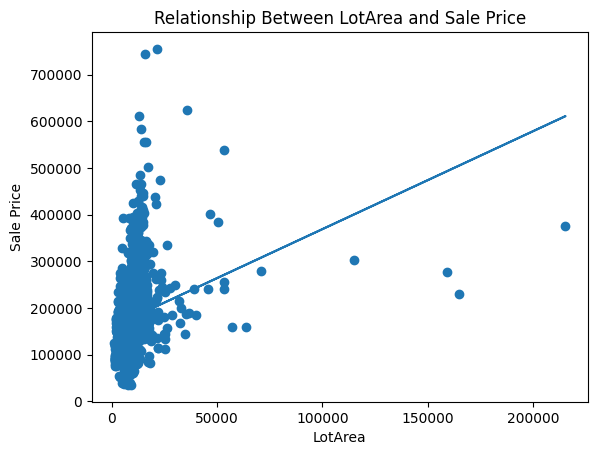

OverallQual
R-squared: 0.625651892462118


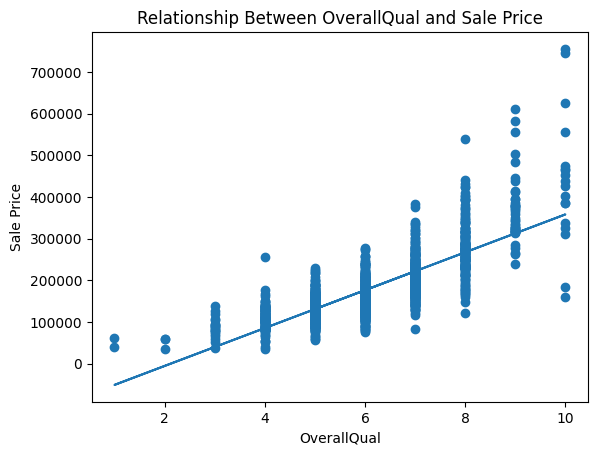

OverallCond
R-squared: 0.00606154023811889


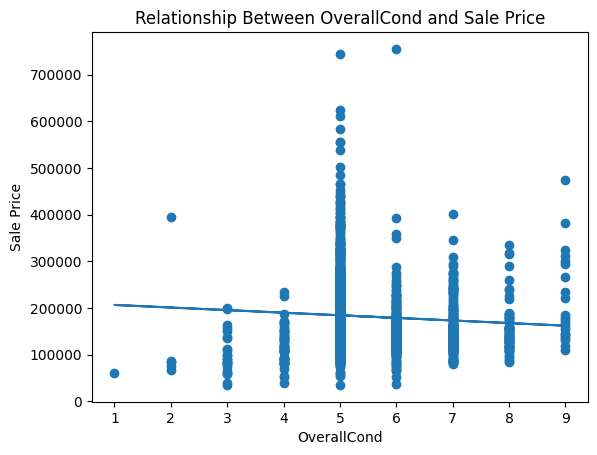

YearBuilt
R-squared: 0.27342162073249154


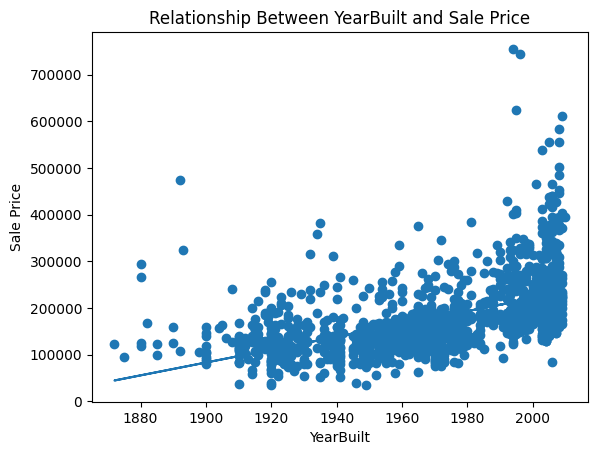

YearRemodAdd
R-squared: 0.25715139084530325


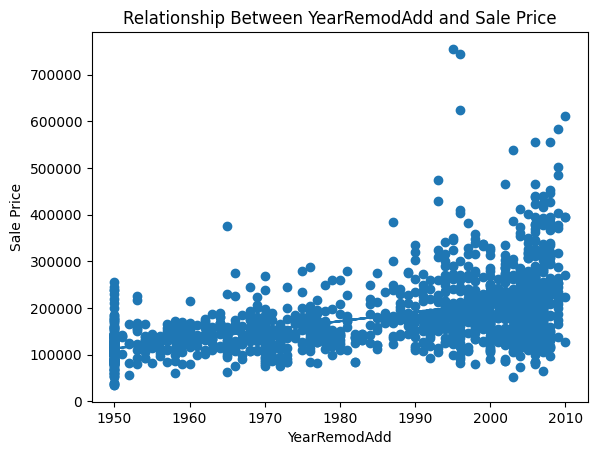

BsmtFinSF1
R-squared: 0.14932026665622333


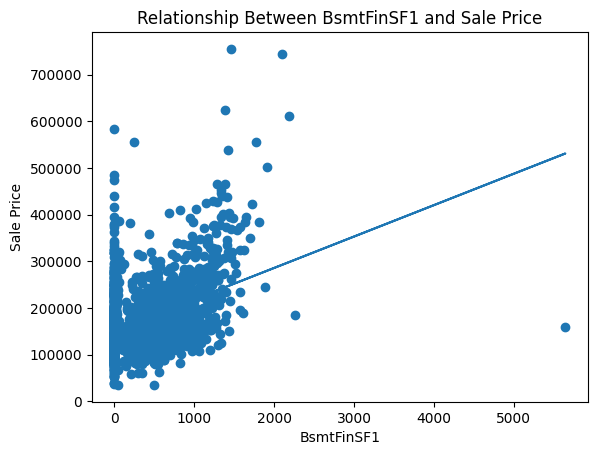

BsmtUnfSF
R-squared: 0.04600128671622783


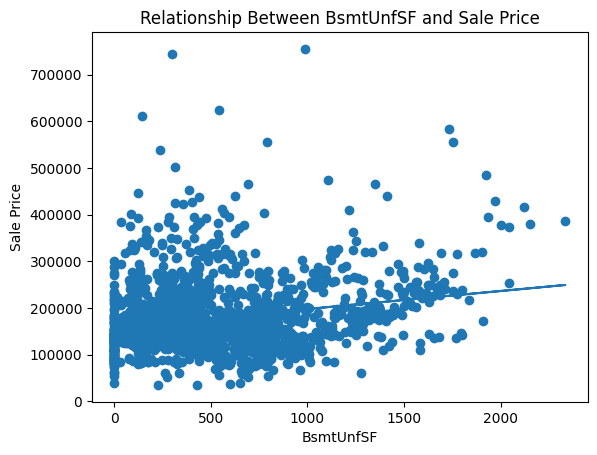

TotalBsmtSF
R-squared: 0.37648109325168655


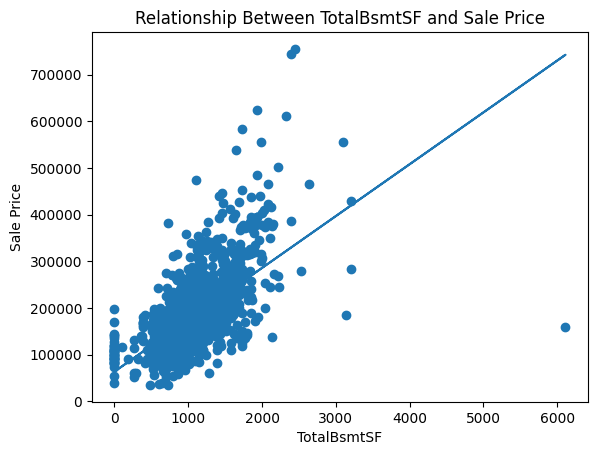

1stFlrSF
R-squared: 0.36705686969596585


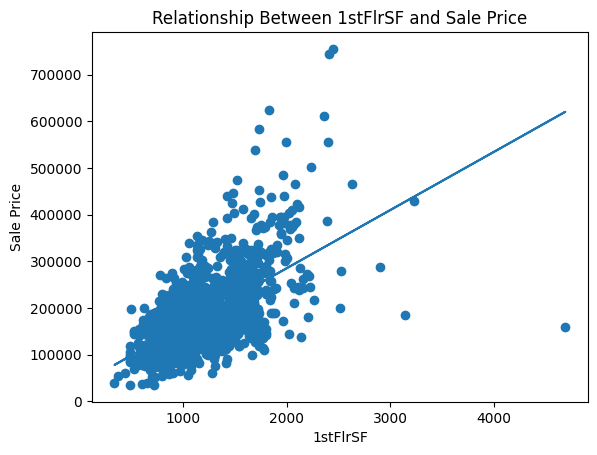

2ndFlrSF
R-squared: 0.10197407763119004


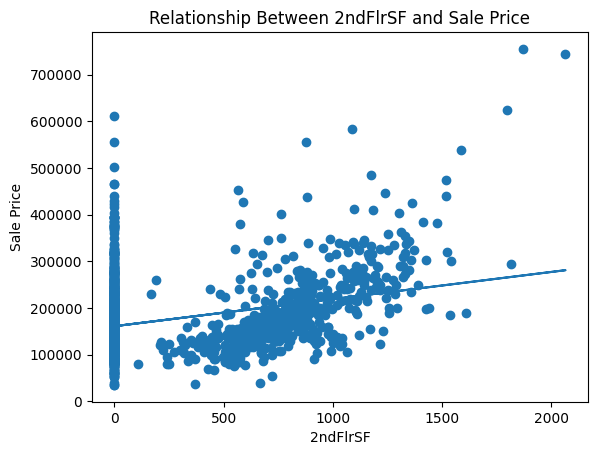

GrLivArea
R-squared: 0.5021486502718042


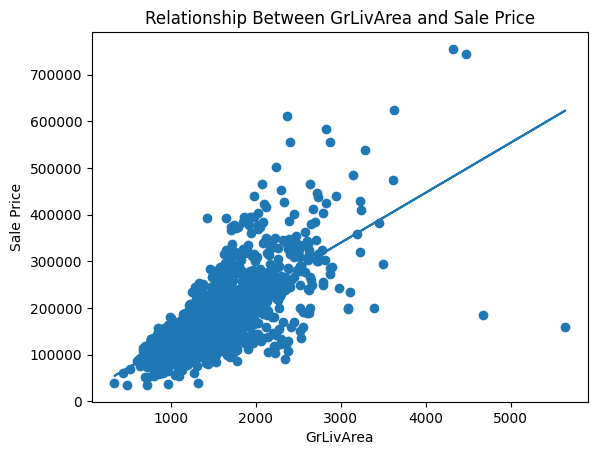

TotRmsAbvGrd
R-squared: 0.2848604068044379


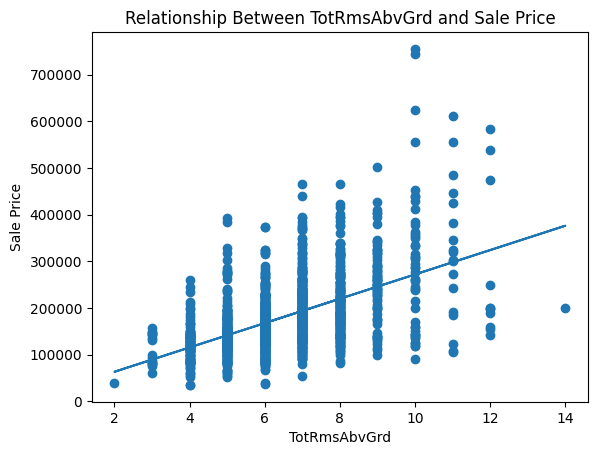

Fireplaces
R-squared: 0.21802253859013498


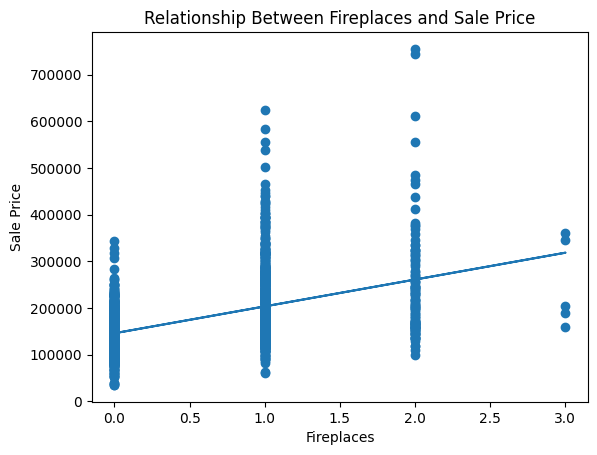

GarageCars
R-squared: 0.41012393993308693


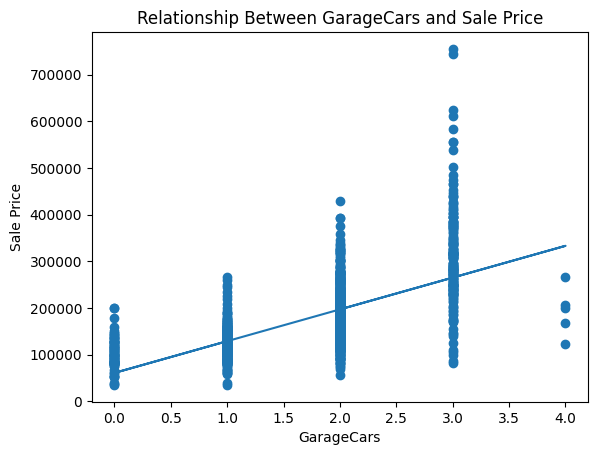

GarageArea
R-squared: 0.388666759031819


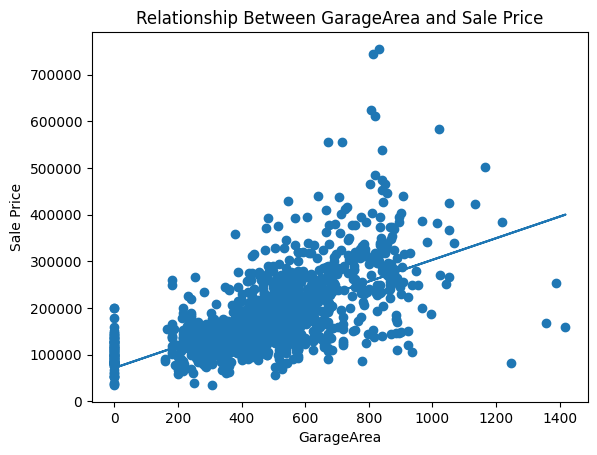

WoodDeckSF
R-squared: 0.10524408301655919


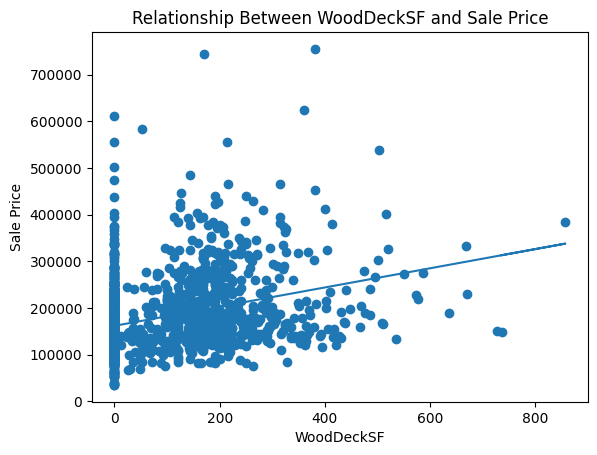

SalePrice
R-squared: 1.0


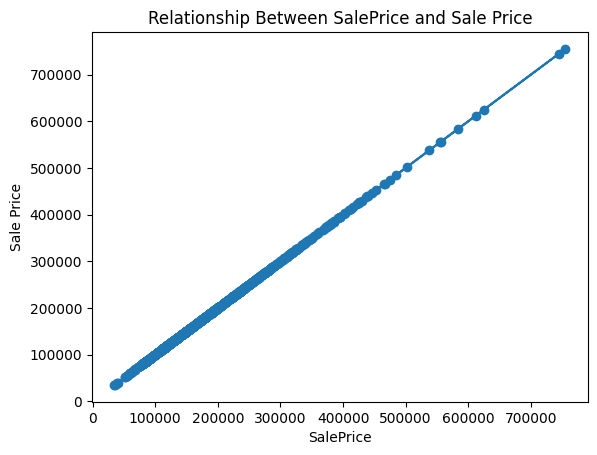

In [ ]:
prices = df['SalePrice'].tolist()
for name, data in df.items():
  print(name)
  data = np.array(data).reshape(-1, 1)
  model = sklearn.linear_model.LinearRegression()
  model.fit(data, prices)
  guesses = model.predict(data)
  print('R-squared: ' + str(model.score(data, prices)))
  plt.scatter(data, prices)
  plt.plot(data, guesses)
  plt.xlabel(name)
  plt.ylabel('Sale Price')
  plt.title('Relationship Between ' + str(name) + ' and Sale Price')
  plt.show()

In [ ]:
#Ridge Regression w/o Standardization, Various Lambda Values
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(df.drop('SalePrice', axis=1), df['SalePrice'], test_size=0.2, random_state=42)
a_val = 1
a_vals = []
coefs = []

for i in range(10):
  a_vals.append(math.log10(a_val))
  model = sklearn.linear_model.Ridge(alpha=a_val)
  model.fit(X_train,y_train)
  guesses = model.predict(X_test)
  print('Iteration ' + str(i+1) + ' MSE: ' + str(sklearn.metrics.mean_squared_error(guesses, y_test)))
  print('Iteration ' + str(i+1) + ' R-squared: ' + str(model.score(X_test, y_test)))
  a_val = a_val * 10
  coefs.append(model.coef_)

Iteration 1 MSE: 1452608495.010462
Iteration 1 R-squared: 0.8106197238848378
Iteration 2 MSE: 1451076316.431525
Iteration 2 R-squared: 0.8108194779158335
Iteration 3 MSE: 1445160224.8620288
Iteration 3 R-squared: 0.8115907738698378
Iteration 4 MSE: 1507706686.2145796
Iteration 4 R-squared: 0.8034364321035196
Iteration 5 MSE: 1675589733.261832
Iteration 5 R-squared: 0.78154909087285
Iteration 6 MSE: 1716413632.8694255
Iteration 6 R-squared: 0.7762267749106759
Iteration 7 MSE: 1777848394.5962973
Iteration 7 R-squared: 0.7682173682612812
Iteration 8 MSE: 1962762471.2449708
Iteration 8 R-squared: 0.7441096482434013
Iteration 9 MSE: 2420376189.764767
Iteration 9 R-squared: 0.6844493800671912
Iteration 10 MSE: 4616191987.372714
Iteration 10 R-squared: 0.39817527147055043


In [ ]:
#Ridge Regression w/ Standardization, Various Lambda Values
scaler = sklearn.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
#y_train = scaler.fit_transform(pd.DataFrame(y_train))
#y_test = scaler.fit_transform(pd.DataFrame(y_test))

a_val = 1
a_vals_new = []
coefs_new = []

for i in range(10):
  a_vals_new.append(math.log10(a_val))
  model = sklearn.linear_model.Ridge(alpha=a_val)
  model.fit(X_train,y_train)
  guesses = model.predict(X_test)
  print('Iteration ' + str(i+1) + ' MSE: ' + str(sklearn.metrics.mean_squared_error(guesses, y_test)))
  print('Iteration ' + str(i+1) + ' R-squared: ' + str(model.score(X_test, y_test)))
  a_val = a_val * 10
  coefs_new.append(model.coef_)

Iteration 1 MSE: 1423059308.5252922
Iteration 1 R-squared: 0.8144721267275595
Iteration 2 MSE: 1422467554.0437138
Iteration 2 R-squared: 0.8145492752693027
Iteration 3 MSE: 1443820236.3064337
Iteration 3 R-squared: 0.811765471597079
Iteration 4 MSE: 1744769266.094351
Iteration 4 R-squared: 0.772529978652082
Iteration 5 MSE: 4166172661.010166
Iteration 5 R-squared: 0.456845439362612
Iteration 6 MSE: 7046017085.3945465
Iteration 6 R-squared: 0.08139277325749184
Iteration 7 MSE: 7608828937.589349
Iteration 7 R-squared: 0.008017555960025957
Iteration 8 MSE: 7670212751.556333
Iteration 8 R-squared: 1.4791500091093646e-05
Iteration 9 MSE: 7676406399.291121
Iteration 9 R-squared: -0.0007926901594221825
Iteration 10 MSE: 7677026321.301246
Iteration 10 R-squared: -0.0008735109737370017


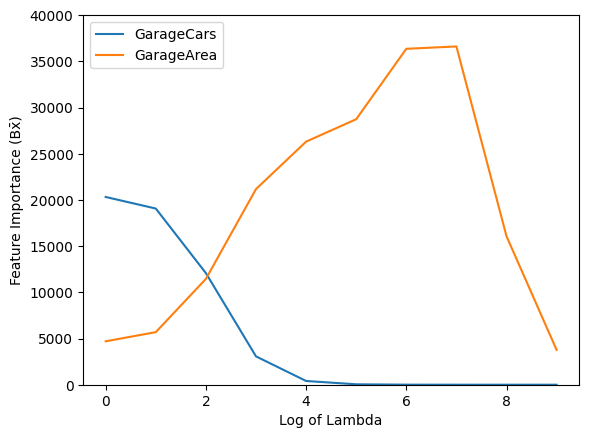

In [ ]:
interest = list(df.columns)
interest = ['OverallQual','GrLivArea']
#interest = ['YearBuilt','YearRemodAdd','GrLivArea']
interest = ['GarageCars','GarageArea']

for i in range(16):
  if df.columns[i] in interest:
    feature = []
    for j in range(len(coefs)):
      feature.append(coefs[j][i] * np.mean(df[df.columns[i]]))
    plt.plot(a_vals, feature)
plt.legend(interest)
plt.xlabel('Log of Lambda')
plt.ylabel('Feature Importance (Bx̄)')
#plt.title('Ridge Regression Selection of Features Across Lambda Values')
plt.ylim(0, 40000)
plt.show()

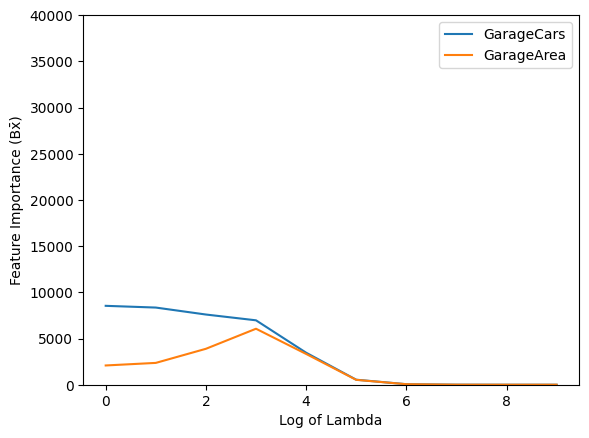

In [ ]:
interest = list(df.columns)
interest = ['OverallQual','GrLivArea']
#interest = ['YearBuilt','YearRemodAdd','GrLivArea']
interest = ['GarageCars','GarageArea']

for i in range(16):
  if df.columns[i] in interest:
    feature = []
    for j in range(len(coefs)):
      feature.append(coefs_new[j][i])
    plt.plot(a_vals_new, feature)
plt.legend(interest)
plt.xlabel('Log of Lambda')
plt.ylabel('Feature Importance (Bx̄)')
#plt.title('Ridge Regression Selection of Features Across Lambda Values')
plt.ylim(0, 40000)
plt.show()